## Relación entre ventas y personal activo

In [1]:
# Cargamos los datos de ventas

import pandas as pd

ventas_2024 = pd.read_csv(
    "data/sales_hourly/sales_per_hour_2024.csv"
)

ventas_2025 = pd.read_csv(
    "data/sales_hourly/sales_per_hour_2025.csv"
)

ventas_2026 = pd.read_csv(
    "data/sales_hourly/sales_per_hour_2026.csv"
)

ventas = pd.concat(
    [ventas_2024, ventas_2025, ventas_2026],
    ignore_index=True
)

ventas["datetime"] = pd.to_datetime(
    ventas["datetime"]
)

ventas.head()

,datetime,ventas
0,2024-01-01 15:00:00,200.6
1,2024-01-01 16:00:00,174.9
2,2024-01-01 17:00:00,204.9
3,2024-01-01 18:00:00,282.2
4,2024-01-01 19:00:00,249.8


In [2]:
# Cargamos los turnos de trabajo

horarios = pd.read_excel("data/inputs/horarios.xlsx")

horarios["fecha"] = pd.to_datetime(
    horarios["fecha"],
    dayfirst=True
)

horarios["entrada"] = pd.to_datetime(
    horarios["entrada"].astype(str),
    format="%H:%M:%S"
).dt.time

horarios["duracion_turno"] = (
    horarios["duracion_turno"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

horarios.head()

,semana,dia,fecha,worker_id,entrada,duracion_turno
0,1,1,2024-08-05,0,18:00:00,8.0
1,1,1,2024-08-05,2,13:00:00,8.0
2,1,1,2024-08-05,3,12:30:00,8.0
3,1,1,2024-08-05,5,18:30:00,7.5
4,1,1,2024-08-05,8,12:30:00,9.0


In [3]:
# Transformamos los turnos en registros por hora

from datetime import timedelta

registros = []

for _, fila in horarios.iterrows():

    inicio = pd.Timestamp.combine(
        fila["fecha"],
        fila["entrada"]
    )

    fin = inicio + timedelta(
        hours=fila["duracion_turno"]
    )

    hora = inicio.floor("h")

    while hora < fin:

        registros.append({
            "datetime": hora
        })

        hora += timedelta(hours=1)

personas = (
    pd.DataFrame(registros)
      .groupby("datetime")
      .size()
      .reset_index(name="personas")
)

personas.head()

,datetime,personas
0,2024-08-05 12:00:00,2
1,2024-08-05 13:00:00,3
2,2024-08-05 14:00:00,3
3,2024-08-05 15:00:00,3
4,2024-08-05 16:00:00,3


In [4]:
# COnstruimos dataset con ventas y personal

df = ventas.merge(
    personas,
    on="datetime",
    how="inner"
)

df.head()

,datetime,ventas,personas
0,2024-08-05 12:00:00,42.9,2
1,2024-08-05 13:00:00,84.6,3
2,2024-08-05 14:00:00,103.6,3
3,2024-08-05 15:00:00,194.7,3
4,2024-08-05 16:00:00,314.1,3


In [5]:
# Limpieza del dataset

df = df[
    (df["ventas"] >= 1)
    &
    (df["personas"] > 0)
].copy()

df.reset_index(drop=True, inplace=True)

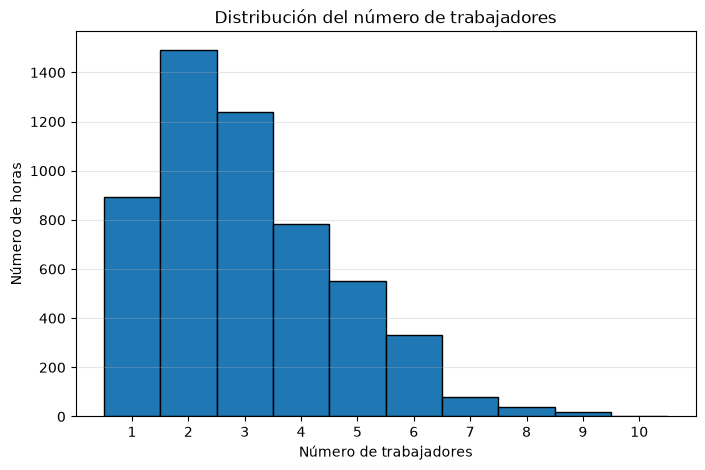

In [6]:
# Histograma del número de trabajadores

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["personas"],
    bins=range(
        int(df["personas"].min()),
        int(df["personas"].max()) + 2
    ),
    edgecolor="black",
    align="left"
)

plt.xticks(
    range(
        int(df["personas"].min()),
        int(df["personas"].max()) + 1
    )
)

plt.xlabel("Número de trabajadores")
plt.ylabel("Número de horas")
plt.title("Distribución del número de trabajadores")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [7]:
# Frecuencia del número de trabajadores

frecuencias = (
    df["personas"]
    .value_counts()
    .sort_index()
    .rename("Horas")
    .to_frame()
)

frecuencias["Porcentaje"] = (
    frecuencias["Horas"]
    / frecuencias["Horas"].sum()
    * 100
).round(2)

frecuencias

,Horas,Porcentaje
personas,,
1,895,16.49
2,1492,27.49
3,1237,22.79
4,784,14.45
5,553,10.19
6,330,6.08
7,79,1.46
8,37,0.68
9,17,0.31


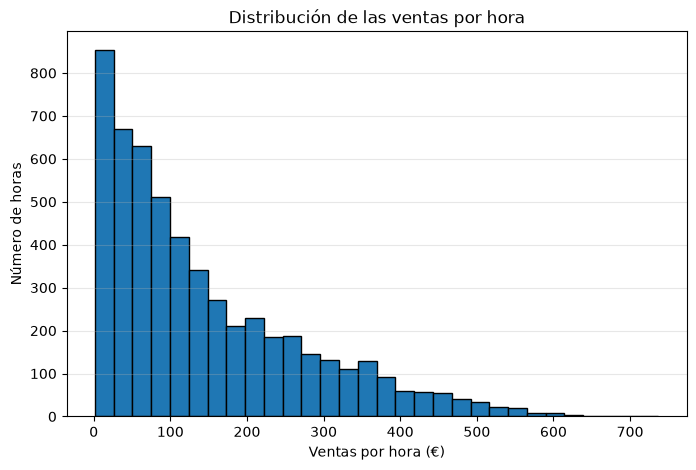

In [8]:
# Histograma de las ventas por hora

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["ventas"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Ventas por hora (€)")
plt.ylabel("Número de horas")
plt.title("Distribución de las ventas por hora")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [9]:
df["ventas"].describe().round(2)

count    5427.00
mean      144.10
std       128.84
min         1.40
25%        43.95
50%       102.10
75%       213.85
max       737.00
Name: ventas, dtype: float64

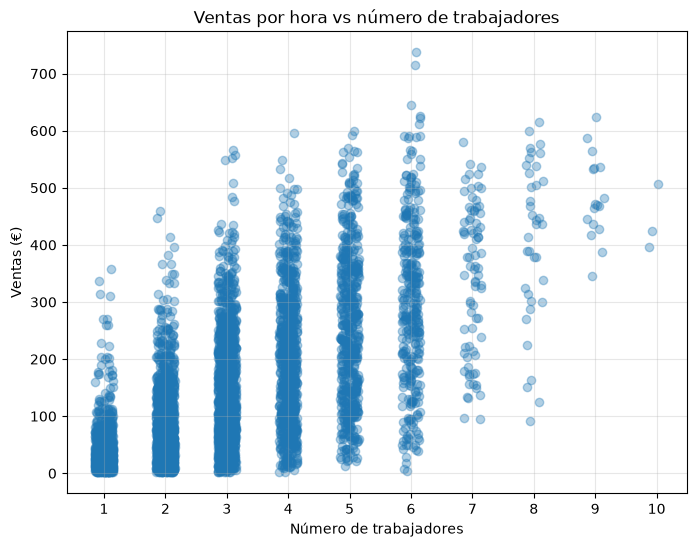

In [10]:
# Relación entre ventas y número de trabajadores. Scatter plot

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

x = (
    df["personas"]
    + np.random.uniform(-0.15, 0.15, len(df))
)

plt.scatter(
    x,
    df["ventas"],
    alpha=0.35
)

plt.xticks(sorted(df["personas"].unique()))

plt.xlabel("Número de trabajadores")
plt.ylabel("Ventas (€)")
plt.title("Ventas por hora vs número de trabajadores")

plt.grid(alpha=0.3)

plt.show()

<Figure size 1000x600 with 0 Axes>

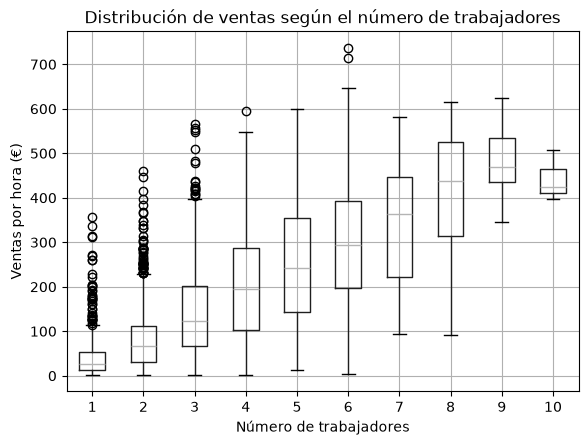

In [11]:
# Boxplot de ventas por número de trabajadores

plt.figure(figsize=(10,6))

df.boxplot(column="ventas", by="personas")

plt.xlabel("Número de trabajadores")
plt.ylabel("Ventas por hora (€)")
plt.title("Distribución de ventas según el número de trabajadores")
plt.suptitle("")
plt.show()

In [12]:
# Tabla ventas por nuemro de trabajador

resumen = (
    df.groupby("personas")
      .agg(
          horas=("ventas","count"),
          venta_media=("ventas","mean"),
          venta_mediana=("ventas","median"),
          venta_std=("ventas","std"),
          venta_min=("ventas","min"),
          venta_max=("ventas","max")
      )
      .round(2)
)

resumen

,horas,venta_media,venta_mediana,venta_std,venta_min,venta_max
personas,,,,,,
1,895,40.55,27.00,43.62,1.8,357.7
2,1492,80.42,67.55,64.85,1.4,459.9
3,1237,142.51,122.70,97.57,1.5,566.3
4,784,202.34,194.80,117.97,1.8,595.7
5,553,254.08,241.80,132.23,12.4,600.1
6,330,298.56,293.35,144.44,4.1,737.0
7,79,343.36,363.40,128.32,94.3,581.0
8,37,409.79,437.50,140.71,91.9,616.1
9,17,482.30,470.30,73.10,345.2,623.4


In [13]:
# Tabla ventas por horas

resumen_hora = (
    df.groupby(df["datetime"].dt.hour)
      .agg(
          horas=("ventas", "count"),
          ventas_medias=("ventas", "mean"),
          ventas_mediana=("ventas", "median"),
          trabajadores_medios=("personas", "mean")
      )
      .round(2)
)

resumen_hora["ventas_por_trabajador"] = (
    resumen_hora["ventas_medias"] /
    resumen_hora["trabajadores_medios"]
).round(2)

resumen_hora

,horas,ventas_medias,ventas_mediana,trabajadores_medios,ventas_por_trabajador
datetime,,,,,
0,176,116.04,90.00,2.65,43.79
1,39,36.68,30.60,2.77,13.24
12,309,21.01,15.20,1.08,19.45
13,399,39.56,30.60,1.46,27.10
14,433,68.54,56.00,1.64,41.79
15,452,139.44,106.85,2.60,53.63
16,457,178.40,136.10,3.23,55.23
17,458,180.96,143.10,3.98,45.47
18,459,231.14,203.70,4.36,53.01


Aqui hay un punto importante que veo, entre las 19:00 y las 20:00 las ventas caen un 32% pero el numero medio de trabadores sigue identico, suponemos que por esperar a despues de cenas, pero en verdad no repunta tanto, solo hasta 136

Las 22:00 la hora mas productiva del dia, 64 euros por trabajador

In [14]:
dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

df["hora"] = df["datetime"].dt.hour
df["dia_semana"] = df["datetime"].dt.dayofweek.map(dias)

df["dia_semana"] = pd.Categorical(
    df["dia_semana"],
    categories=orden_dias,
    ordered=True
)

ventas_hora_dia = pd.pivot_table(
    df,
    values="ventas",
    index="hora",
    columns="dia_semana",
    aggfunc="mean"
).round(1)

ventas_hora_dia

dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
hora,,,,,,,
0,107.8,90.7,89.0,107.2,124.1,116.7,125.1
1,34.0,25.5,19.3,14.7,39.7,45.8,42.8
12,16.2,19.6,15.2,14.9,18.9,24.9,31.0
13,29.6,29.4,32.0,24.3,33.3,47.0,69.4
14,47.2,60.2,45.5,48.5,56.5,86.9,122.9
15,83.0,115.2,91.3,100.6,114.3,199.3,253.1
16,113.2,147.8,109.9,113.0,159.8,258.4,325.4
17,122.8,170.8,126.2,137.2,169.1,237.9,292.7
18,175.4,241.4,168.6,185.2,235.5,278.6,333.1


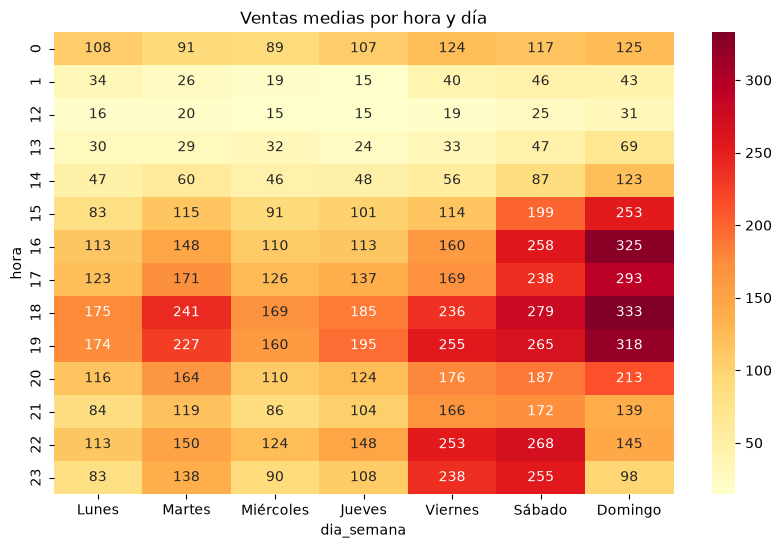

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    ventas_hora_dia,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Ventas medias por hora y día")
plt.show()

In [16]:
trabajadores_hora_dia = pd.pivot_table(
    df,
    values="personas",
    index="hora",
    columns="dia_semana",
    aggfunc="mean"
).round(2)

trabajadores_hora_dia

productividad = (
    ventas_hora_dia /
    trabajadores_hora_dia
).round(1)

productividad

dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
hora,,,,,,,
0,27.0,31.3,37.7,38.0,48.1,51.6,44.7
1,13.6,8.5,11.6,5.3,13.2,17.0,13.9
12,15.9,18.8,14.1,13.3,17.5,22.2,28.7
13,22.1,23.5,26.2,19.3,25.4,28.1,35.2
14,32.8,46.0,33.2,34.9,40.1,42.2,54.9
15,37.6,51.9,44.3,44.9,49.3,64.7,66.3
16,41.0,60.6,43.6,41.7,52.1,64.0,70.0
17,38.1,55.1,40.7,41.7,40.6,45.4,55.9
18,50.0,69.8,50.2,51.9,47.0,49.3,60.8


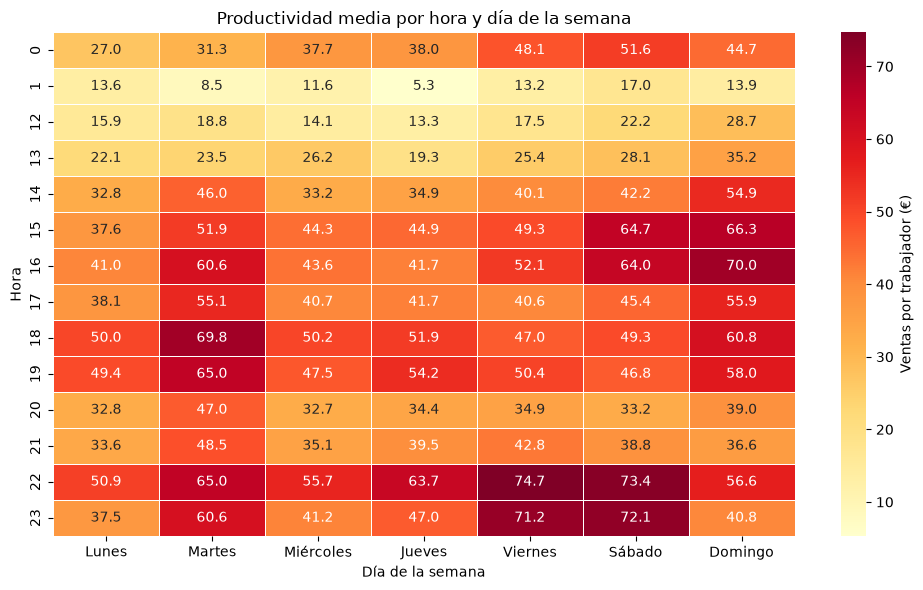

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    productividad,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Ventas por trabajador (€)"}
)

plt.title("Productividad media por hora y día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Hora")

plt.tight_layout()
plt.show()

## Histograma doble ventas, trabajadores por horas

In [18]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Resumen por hora
comparacion = (
    df.groupby(df["datetime"].dt.hour)
      .agg(
          ventas=("ventas", "mean"),
          trabajadores=("personas", "mean")
      )
)

# Normalización
scaler = MinMaxScaler()

comparacion[["ventas_norm", "trabajadores_norm"]] = scaler.fit_transform(
    comparacion[["ventas", "trabajadores"]]
)

comparacion

,ventas,trabajadores,ventas_norm,trabajadores_norm
datetime,,,,
0,116.039205,2.647727,0.452260,0.474937
1,36.676923,2.769231,0.074579,0.511768
12,21.005502,1.080906,0.000000,0.000000
13,39.561404,1.463659,0.088306,0.116021
14,68.541801,1.637413,0.226222,0.168689
15,139.435841,2.599558,0.563603,0.460336
16,178.404595,3.229759,0.749053,0.651364
17,180.959214,3.975983,0.761210,0.877560
18,231.136383,4.361656,1.000000,0.994466


In [19]:
orden_horas = [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1]

comparacion = comparacion.loc[orden_horas]
comparacion = comparacion.reindex(orden_horas)

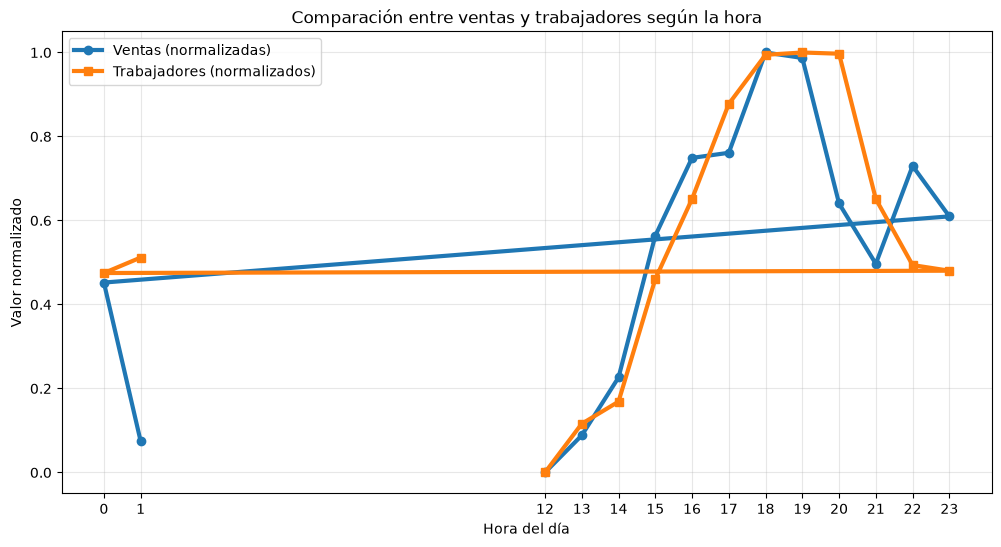

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    comparacion.index,
    comparacion["ventas_norm"],
    marker="o",
    linewidth=3,
    label="Ventas (normalizadas)"
)

plt.plot(
    comparacion.index,
    comparacion["trabajadores_norm"],
    marker="s",
    linewidth=3,
    label="Trabajadores (normalizados)"
)

plt.xticks(comparacion.index)

plt.xlabel("Hora del día")
plt.ylabel("Valor normalizado")
plt.title("Comparación entre ventas y trabajadores según la hora")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

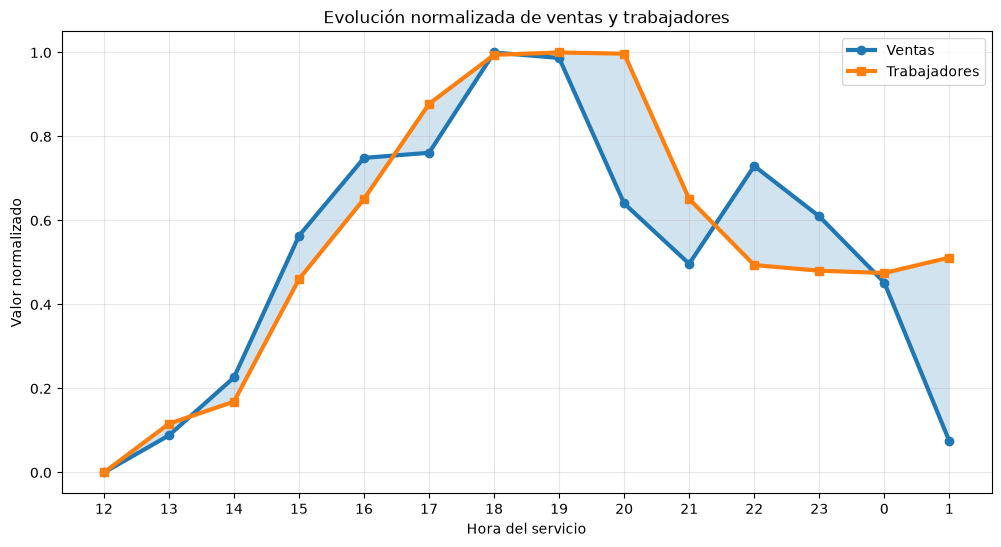

In [21]:
x = range(len(comparacion))

plt.figure(figsize=(12,6))

plt.plot(
    x,
    comparacion["ventas_norm"],
    marker="o",
    linewidth=3,
    label="Ventas"
)

plt.plot(
    x,
    comparacion["trabajadores_norm"],
    marker="s",
    linewidth=3,
    label="Trabajadores"
)

plt.fill_between(
    x,
    comparacion["ventas_norm"],
    comparacion["trabajadores_norm"],
    alpha=0.2
)

plt.xticks(
    x,
    comparacion.index.astype(str)
)

plt.xlabel("Hora del servicio")
plt.ylabel("Valor normalizado")
plt.title("Evolución normalizada de ventas y trabajadores")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

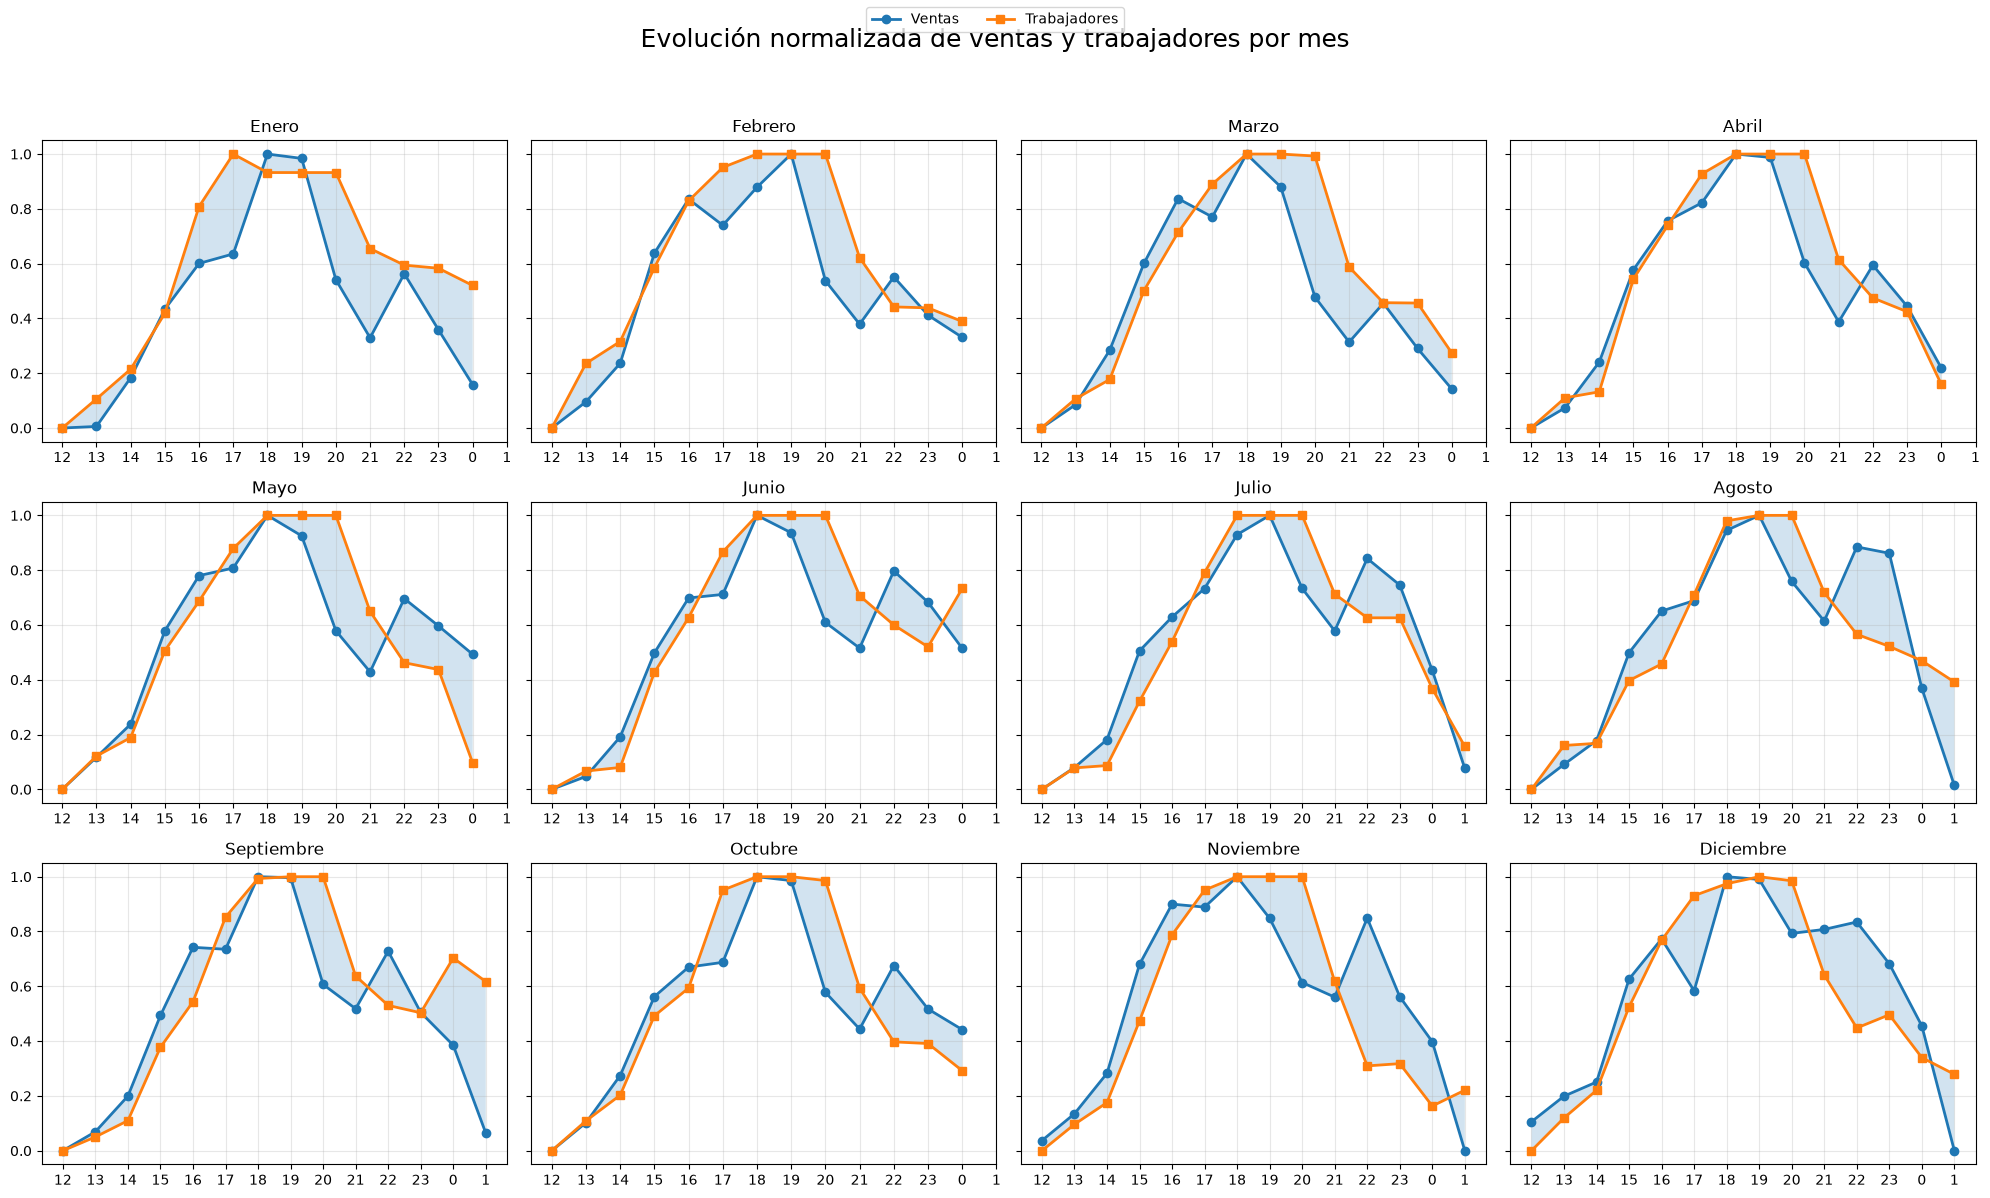

In [22]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

orden_horas = [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1]

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)

meses = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

for mes in range(1, 13):

    datos_mes = df[df["datetime"].dt.month == mes]

    comparacion = (
        datos_mes
        .groupby(datos_mes["datetime"].dt.hour)
        .agg(
            ventas=("ventas", "mean"),
            trabajadores=("personas", "mean")
        )
        .reindex(orden_horas)
    )

    scaler = MinMaxScaler()

    comparacion[["ventas_norm", "trabajadores_norm"]] = (
        scaler.fit_transform(
            comparacion[["ventas", "trabajadores"]]
        )
    )

    x = range(len(comparacion))

    ax = axes[(mes-1)//4, (mes-1)%4]

    ax.plot(
        x,
        comparacion["ventas_norm"],
        marker="o",
        linewidth=2,
        label="Ventas"
    )

    ax.plot(
        x,
        comparacion["trabajadores_norm"],
        marker="s",
        linewidth=2,
        label="Trabajadores"
    )

    ax.fill_between(
        x,
        comparacion["ventas_norm"],
        comparacion["trabajadores_norm"],
        alpha=0.2
    )

    ax.set_xticks(x)
    ax.set_xticklabels(comparacion.index)

    ax.set_title(meses[mes-1])

    ax.grid(alpha=0.3)

fig.suptitle(
    "Evolución normalizada de ventas y trabajadores por mes",
    fontsize=18
)

handles, labels = axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout(rect=[0,0,1,0.95])

plt.show()

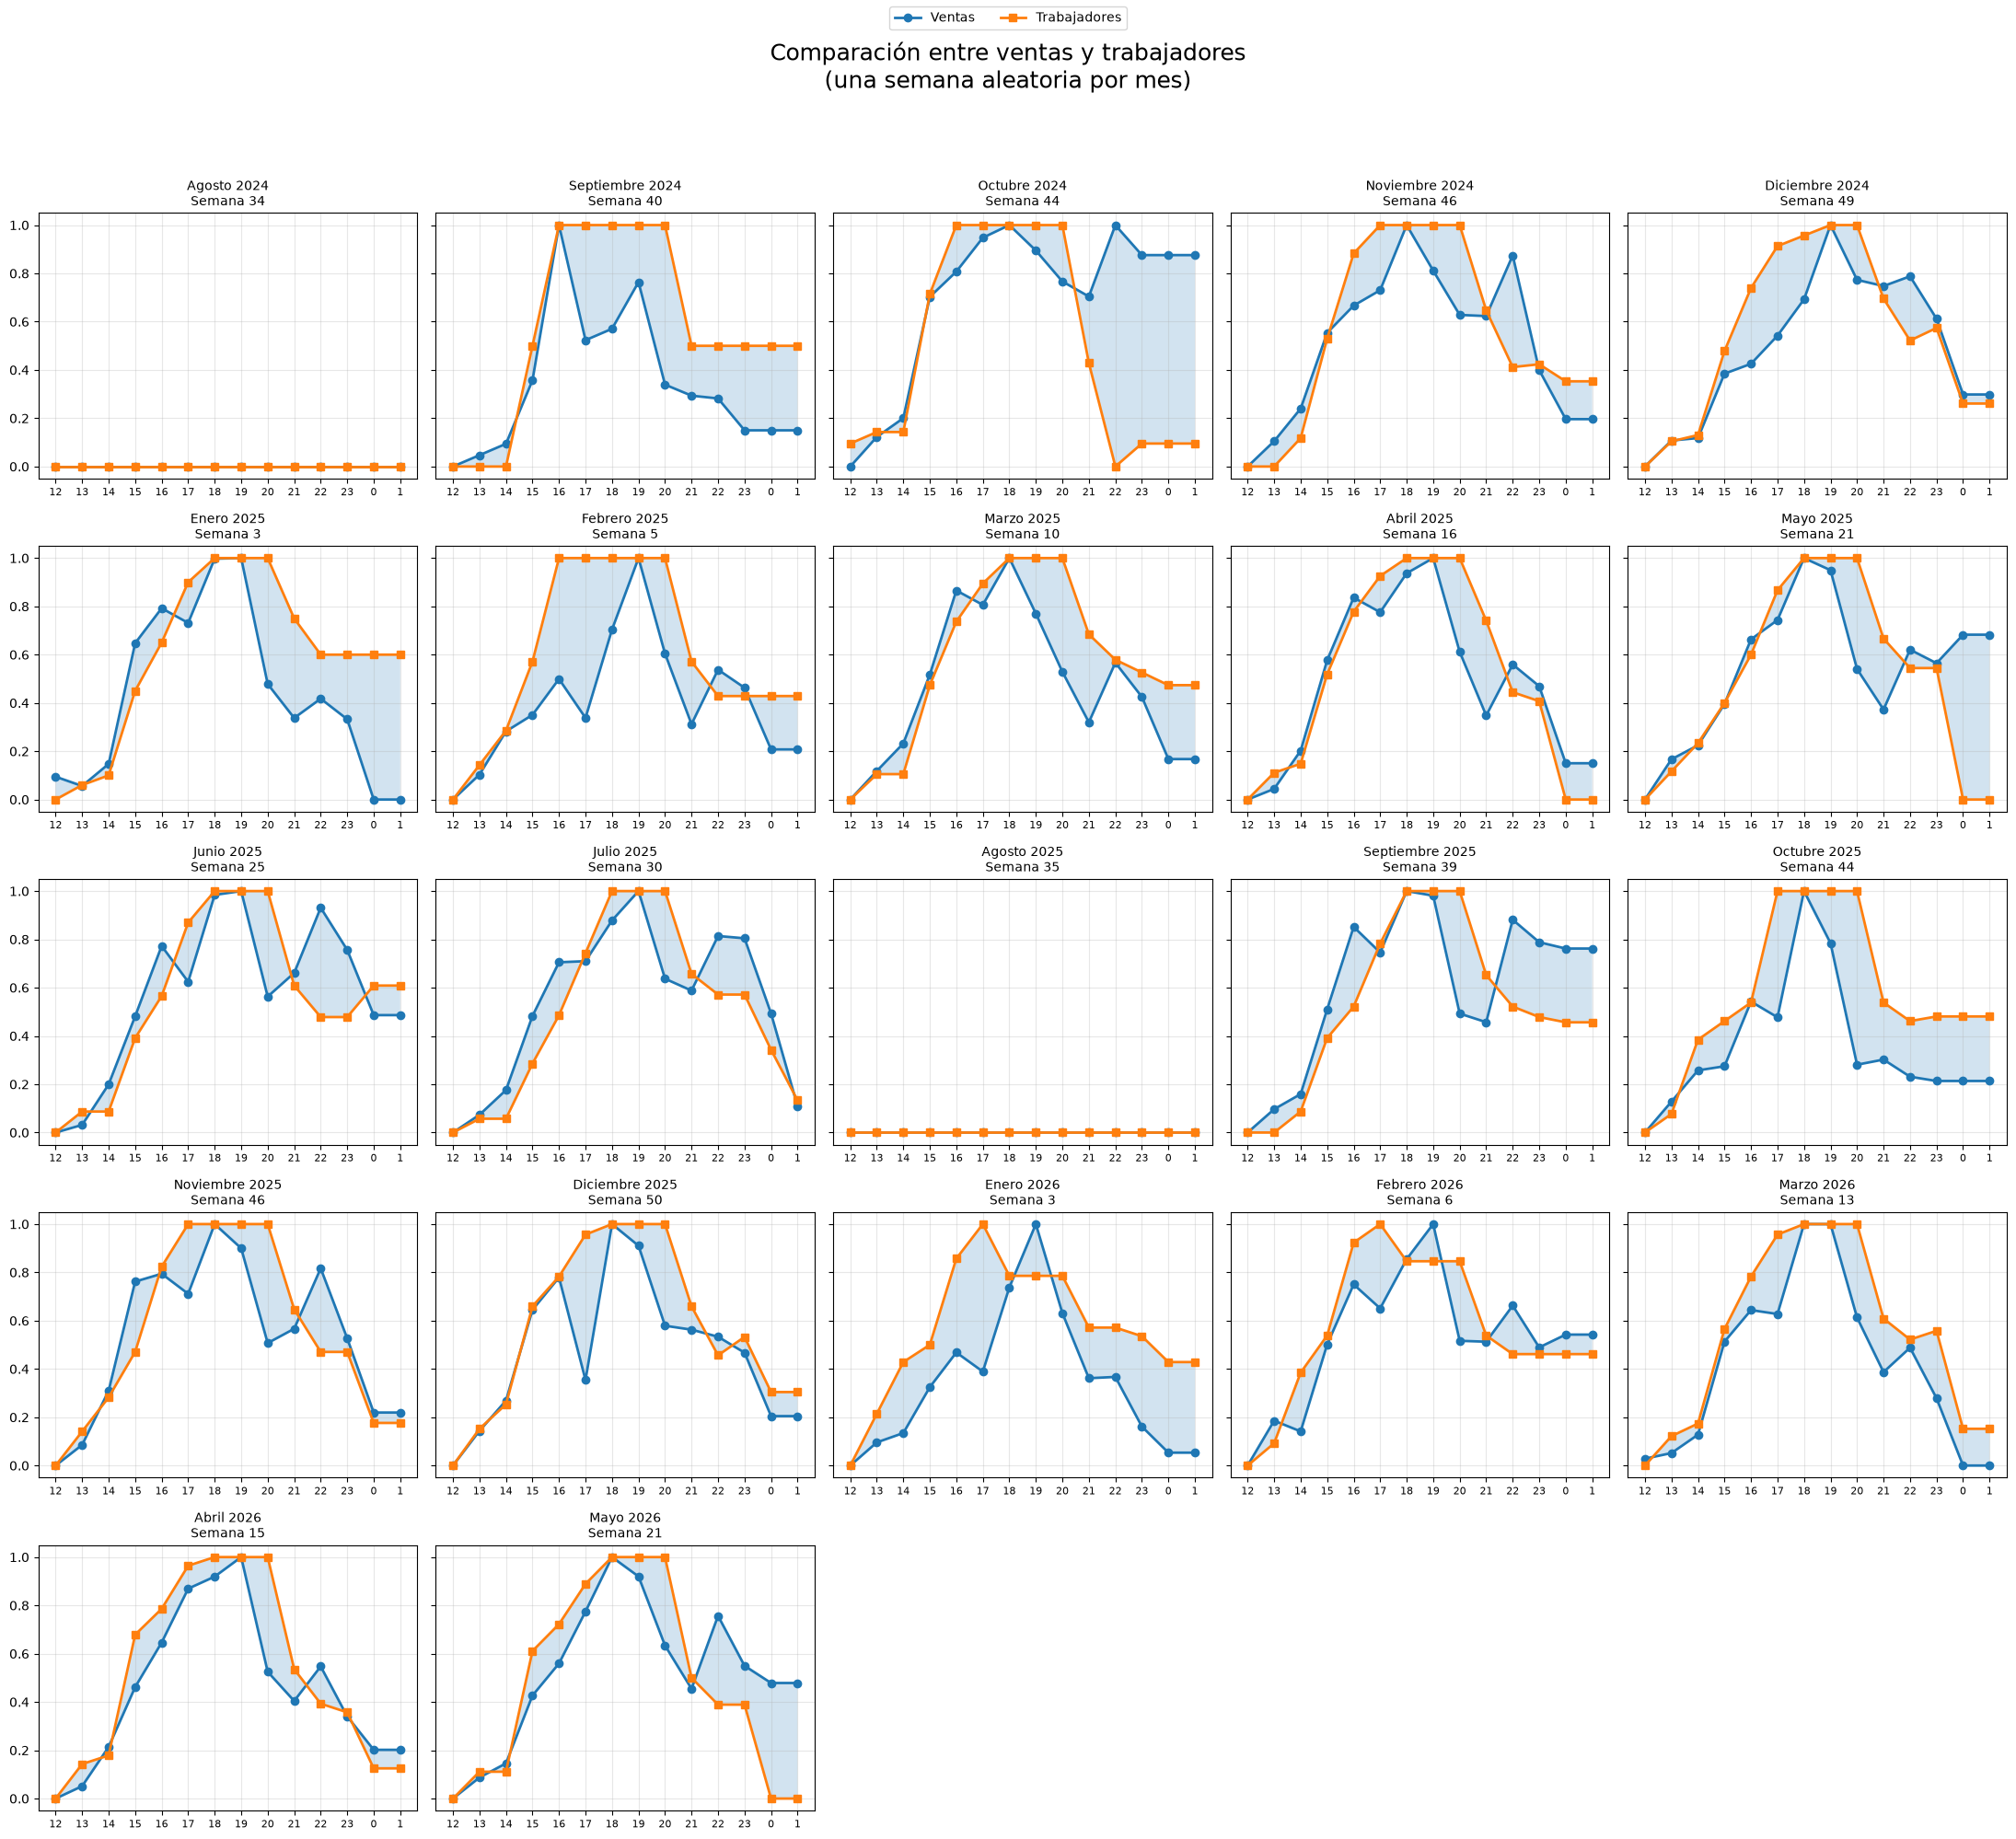

In [28]:
import numpy as np

np.random.seed(42)

# Orden de las horas del servicio
orden_horas = [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1]

# Año y semana ISO
df["anio"] = df["datetime"].dt.year
df["mes"] = df["datetime"].dt.month
df["semana"] = df["datetime"].dt.isocalendar().week

# Semilla para que siempre salgan las mismas semanas
np.random.seed(42)

# Lista de combinaciones año-mes
combinaciones = (
    df[["anio", "mes"]]
    .drop_duplicates()
    .sort_values(["anio", "mes"])
)

n = len(combinaciones)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(22, 4*nrows),
    sharey=True
)

axes = axes.flatten()

meses = [
    "", "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

for ax, (_, fila) in zip(axes, combinaciones.iterrows()):

    anio = fila["anio"]
    mes = fila["mes"]

    datos_mes = df[
        (df["anio"] == anio) &
        (df["mes"] == mes)
    ]

    # Elegir una semana aleatoria del mes
    semanas = datos_mes["semana"].unique()
    semana = np.random.choice(semanas)

    datos = datos_mes[
        datos_mes["semana"] == semana
    ]

    comparacion = (
        datos.groupby(datos["datetime"].dt.hour)
        .agg(
            ventas=("ventas", "mean"),
            trabajadores=("personas", "mean")
        )
        .reindex(orden_horas)
    )

    # Si falta alguna hora, interpolamos para evitar problemas
    comparacion = comparacion.interpolate(limit_direction="both")

    scaler = MinMaxScaler()

    comparacion[["ventas_norm", "trabajadores_norm"]] = (
        scaler.fit_transform(
            comparacion[["ventas", "trabajadores"]]
        )
    )

    x = range(len(comparacion))

    ax.plot(
        x,
        comparacion["ventas_norm"],
        marker="o",
        linewidth=2,
        label="Ventas"
    )

    ax.plot(
        x,
        comparacion["trabajadores_norm"],
        marker="s",
        linewidth=2,
        label="Trabajadores"
    )

    ax.fill_between(
        x,
        comparacion["ventas_norm"],
        comparacion["trabajadores_norm"],
        alpha=0.20
    )

    ax.set_xticks(x)
    ax.set_xticklabels(comparacion.index, fontsize=8)

    ax.set_title(
        f"{meses[mes]} {anio}\nSemana {semana}",
        fontsize=10
    )

    ax.grid(alpha=0.3)

# Ocultar ejes sobrantes
for i in range(n, len(axes)):
    axes[i].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

fig.suptitle(
    "Comparación entre ventas y trabajadores\n(una semana aleatoria por mes)",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [25]:
print(df[df["datetime"].dt.month == 8]["datetime"].dt.hour.value_counts().sort_index())

datetime
0     44
1     24
12    34
13    43
14    44
15    44
16    44
17    44
18    44
19    44
20    44
21    44
22    44
23    44
Name: count, dtype: int64
